<a href="https://colab.research.google.com/github/Faizybro/Faizybro/blob/main/Intern%201st%20task%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of the dataset: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Datase

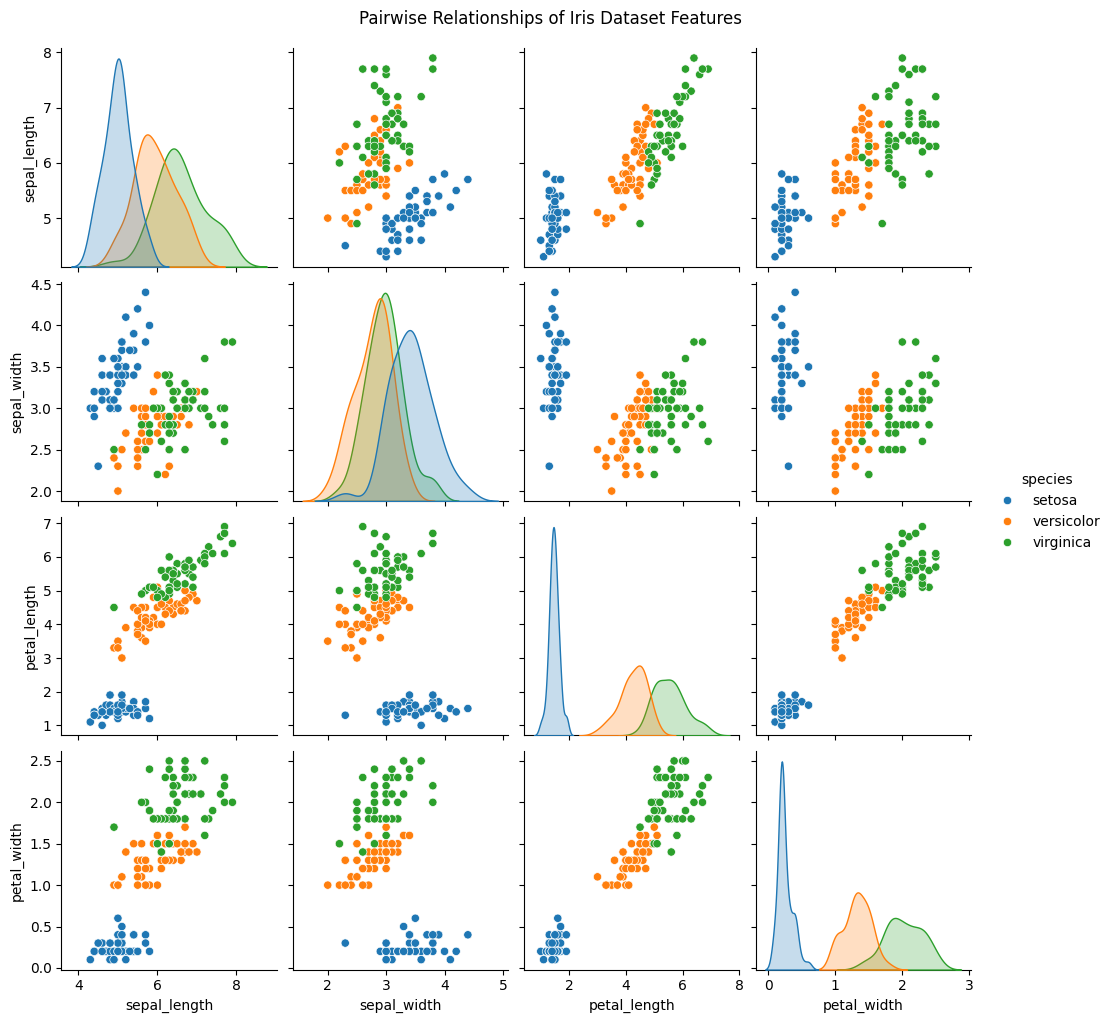

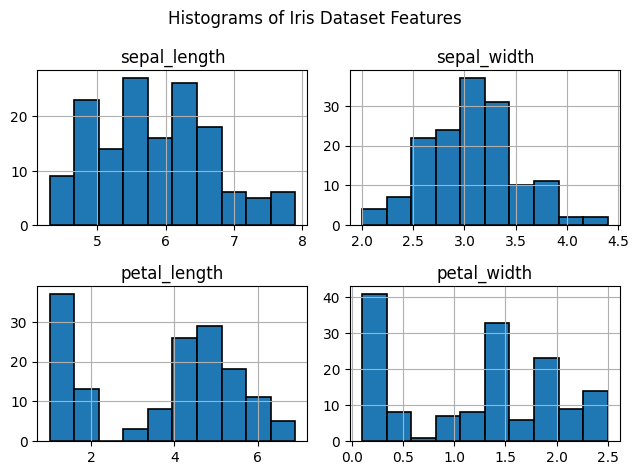

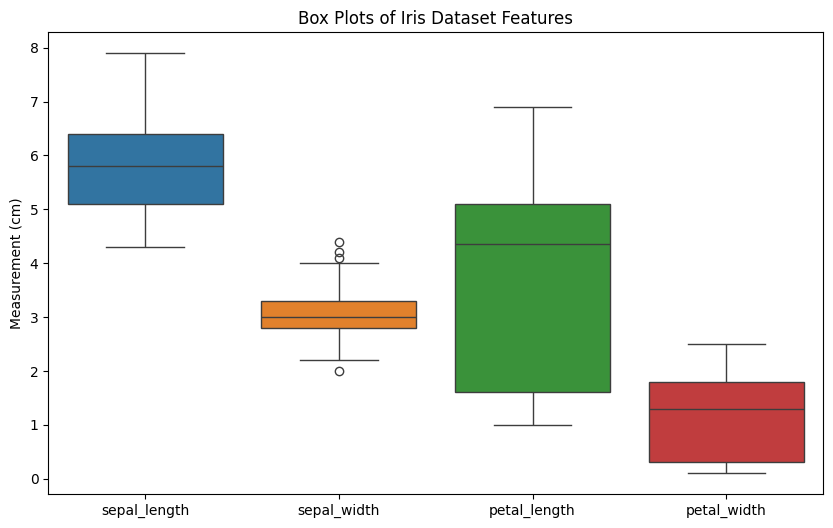

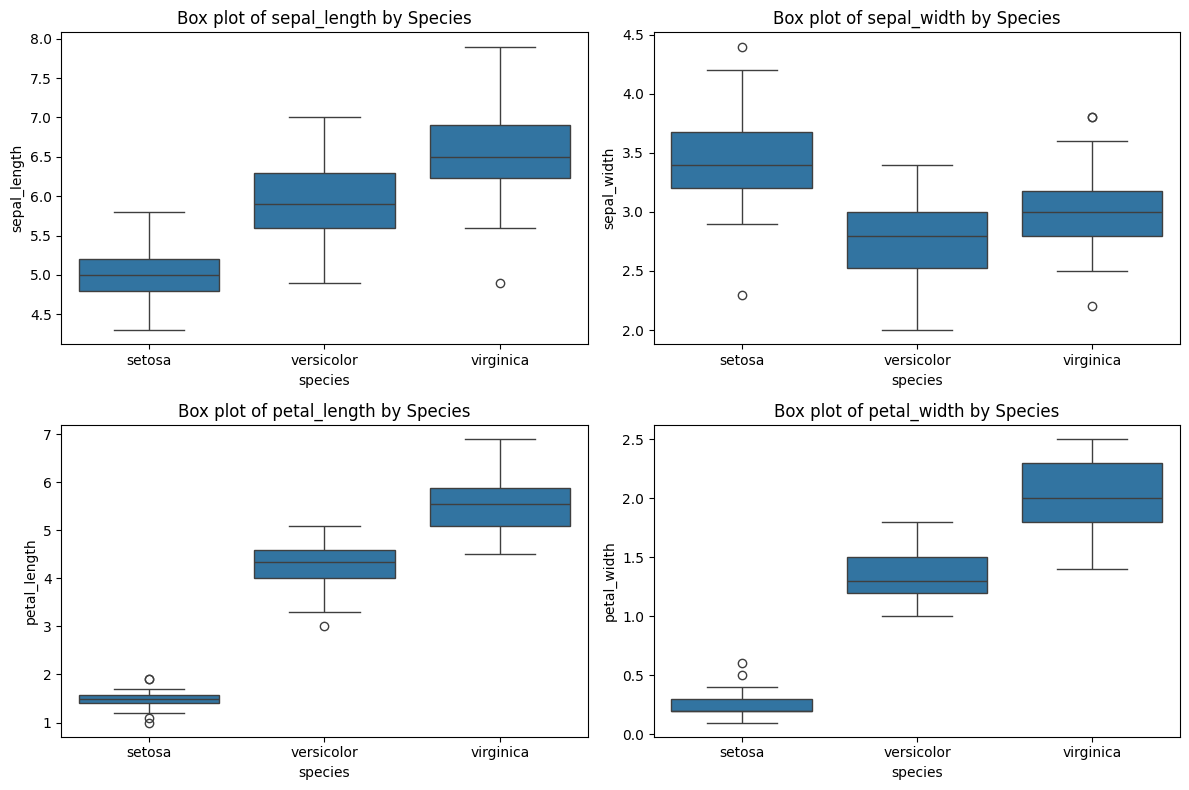

In [ ]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = sns.load_dataset('iris')

# Print shape, column names, and head
print("Shape of the dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

# Use info() and describe()
print("\nDataset Info:\n")
df.info()
print("\nDataset Description:\n")
print(df.describe())

# Visualize the dataset

# Scatter plot of all pairwise relationships
sns.pairplot(df, hue='species')
plt.suptitle("Pairwise Relationships of Iris Dataset Features", y=1.02) # Add title above the plots
plt.show()

# Histograms for feature distributions
df.hist(edgecolor='black', linewidth=1.2)
plt.suptitle("Histograms of Iris Dataset Features")
plt.tight_layout()
plt.show()

# Box plots to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('species', axis=1)) # Drop 'species' for numerical columns
plt.title("Box Plots of Iris Dataset Features")
plt.ylabel("Measurement (cm)")
plt.show()

# Box plot for each feature by species
plt.figure(figsize=(12, 8))
for i, col in enumerate(df.columns[:-1]): # Exclude the 'species' column
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=col, data=df)
    plt.title(f'Box plot of {col} by Species')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2-617087989.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Linear Regression RMSE: 3.367426621543437
Random Forest Regression RMSE: 3.6236851258122016


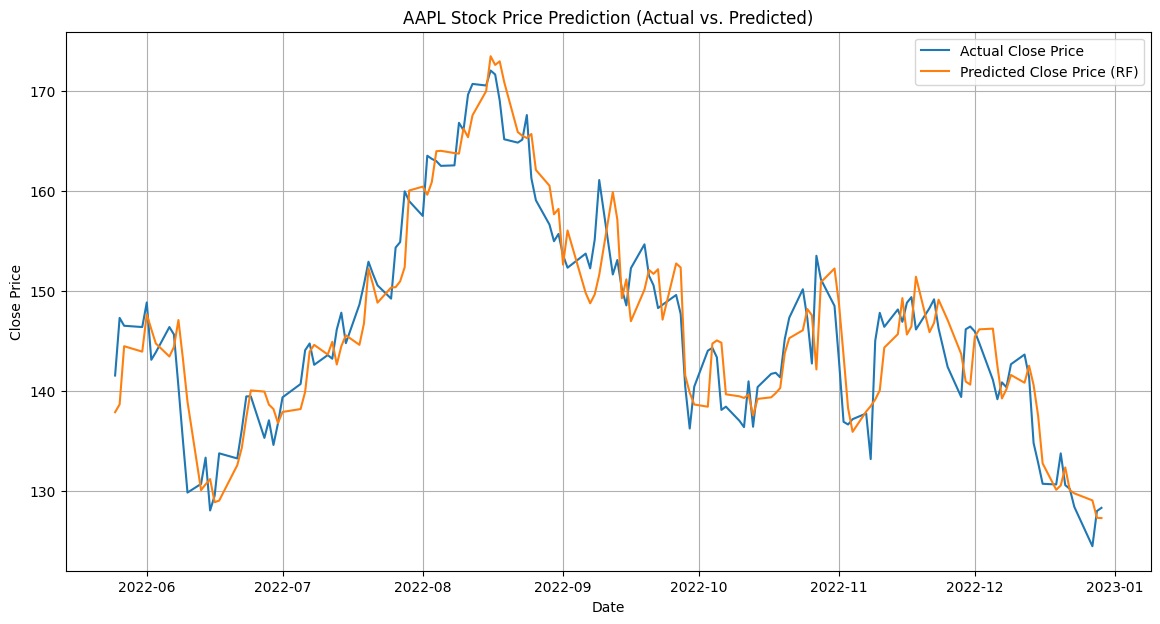

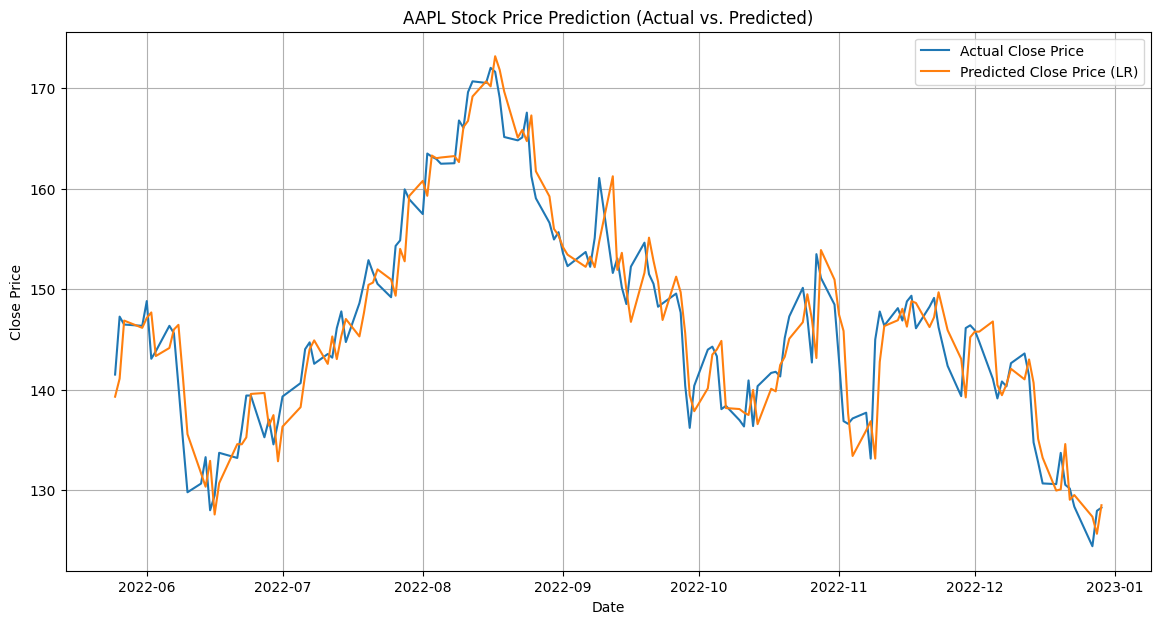

In [ ]:
!pip install yfinance scikit-learn matplotlib

import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Select a stock ticker (e.g., AAPL for Apple, TSLA for Tesla)
stock_ticker = 'AAPL'
start_date = '2020-01-01'
end_date = '2023-01-01' # You can adjust the end date

# Download historical data
data = yf.download(stock_ticker, start=start_date, end=end_date)

# Create features (X) and target (y)
# Features will be the Open, High, Low, and Volume of the current day
# Target will be the Close price of the next day
data['Next_Close'] = data['Close'].shift(-1)

# Drop the last row as it will have a NaN value for Next_Close
data.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Next_Close']

# Split the data into training and testing sets
# Using a time-based split is often more appropriate for time series data
# Let's use the first 80% for training and the last 20% for testing
train_size = int(len(data) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)

# Evaluate the Linear Regression model
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
print(f"Linear Regression RMSE: {linear_rmse}")

# Train a Random Forest Regressor model
# You can tune the parameters like n_estimators
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"Random Forest Regression RMSE: {rf_rmse}")

# Plot actual vs predicted closing prices (using Random Forest for example)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Close Price')
plt.plot(y_test.index, rf_predictions, label='Predicted Close Price (RF)')
plt.title(f'{stock_ticker} Stock Price Prediction (Actual vs. Predicted)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot actual vs predicted closing prices (using Linear Regression for example)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Close Price')
plt.plot(y_test.index, linear_predictions, label='Predicted Close Price (LR)')
plt.title(f'{stock_ticker} Stock Price Prediction (Actual vs. Predicted)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

--2025-06-30 17:16:45--  https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart.csv’

heart.csv               [ <=>                ]  18.03K  --.-KB/s    in 0.1s    

2025-06-30 17:16:46 (140 KB/s) - ‘heart.csv’ saved [18461]

Shape of the dataset after cleaning: (297, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:
     age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    12

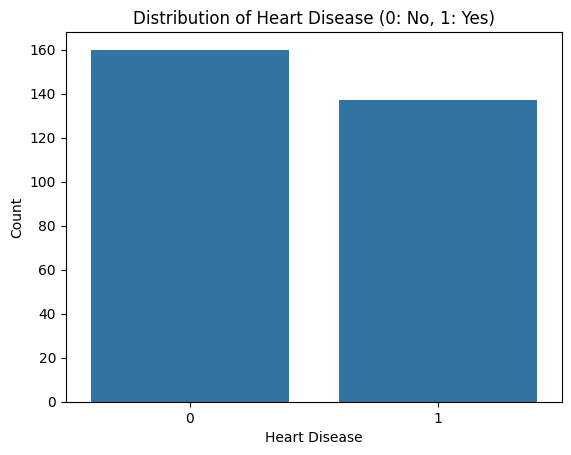

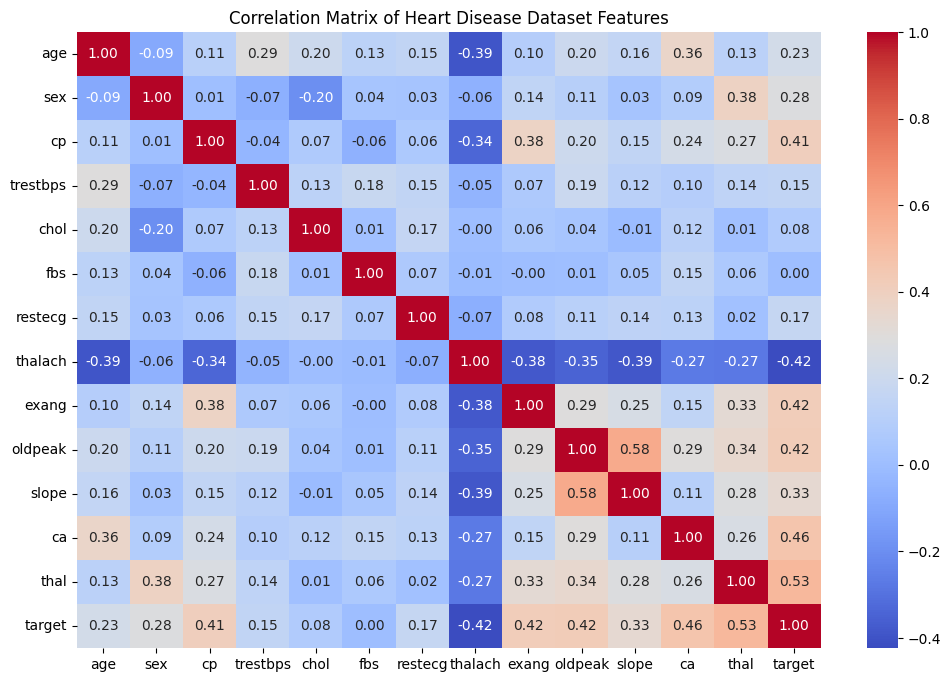

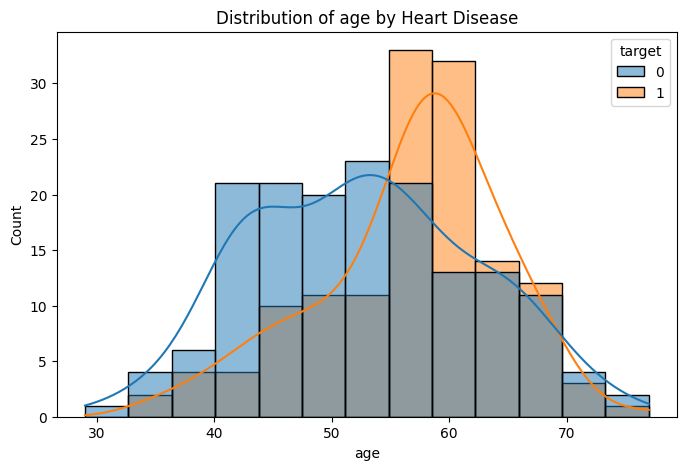

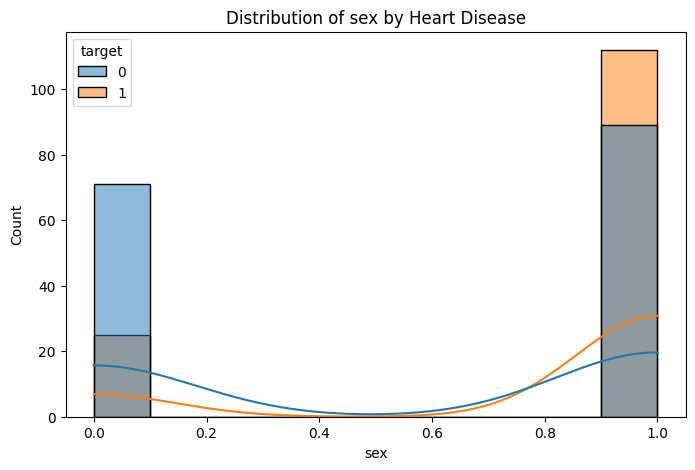

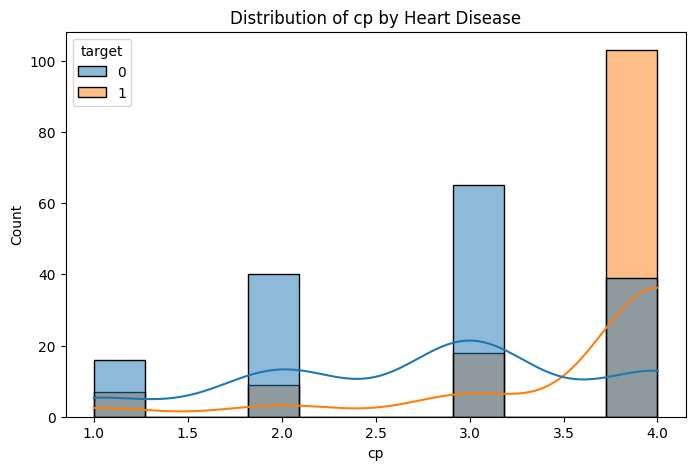

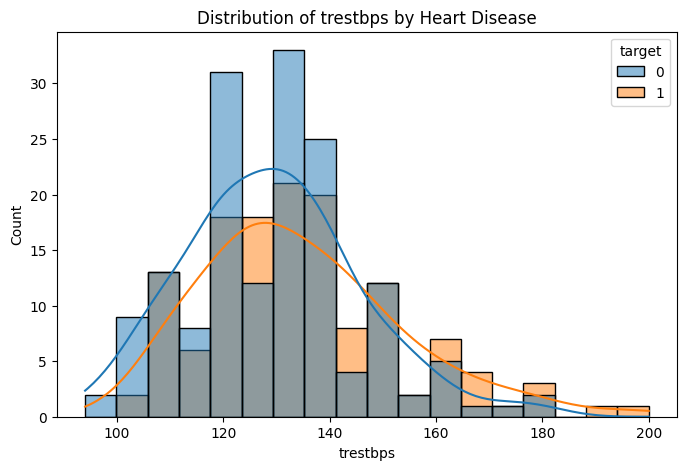

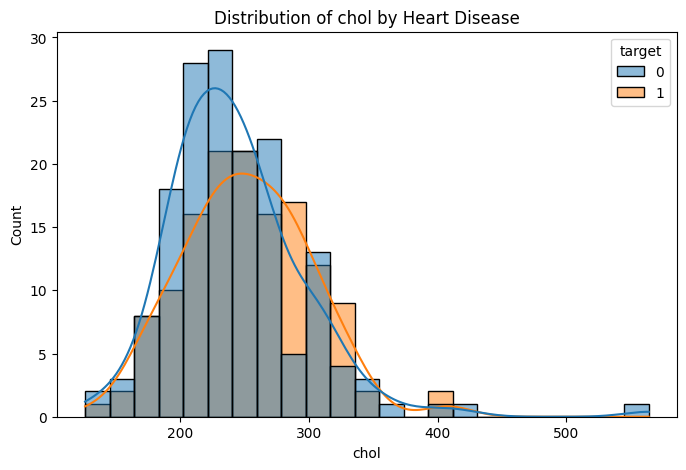

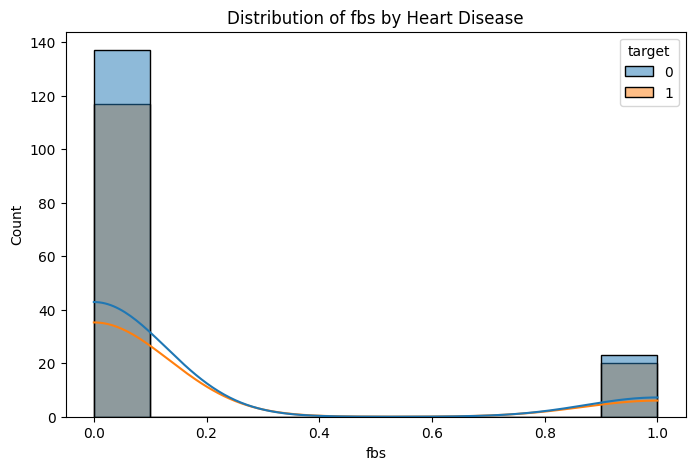

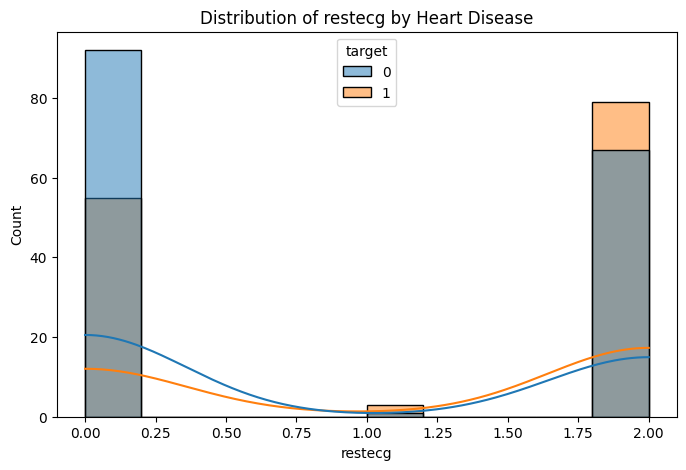

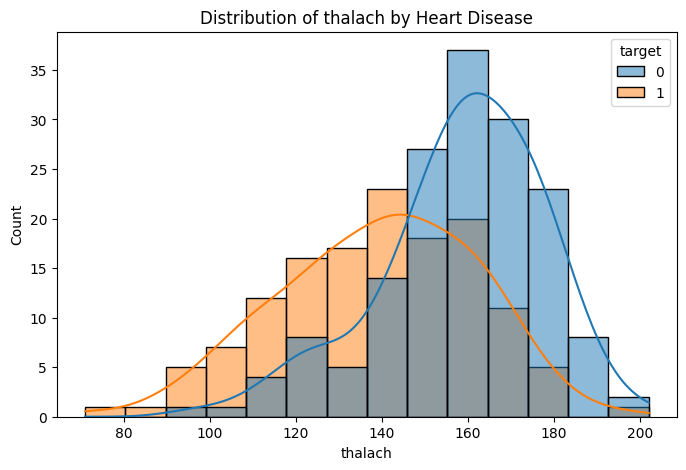

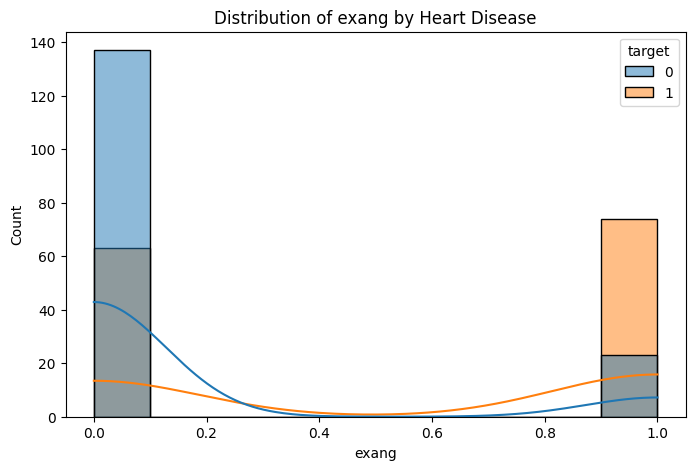

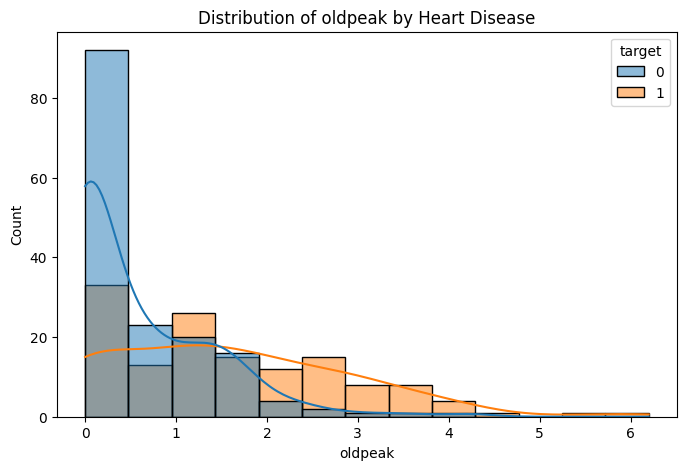

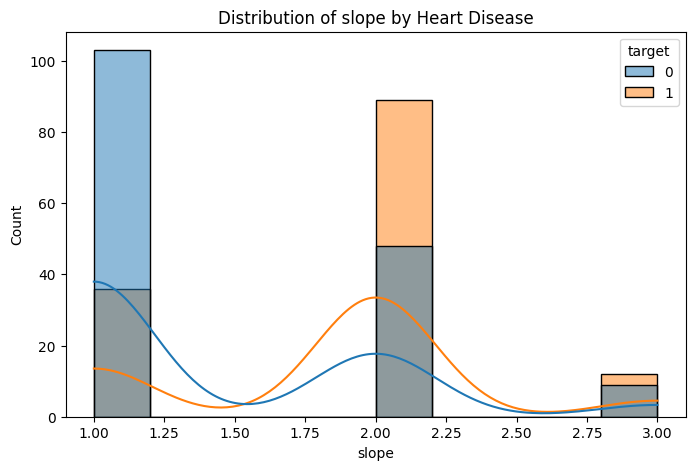

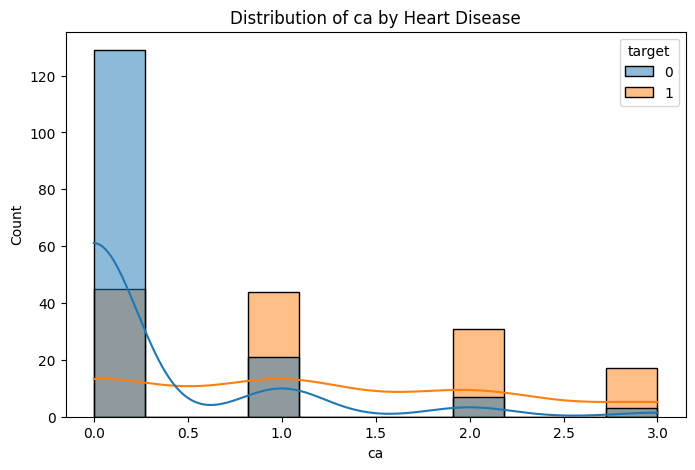

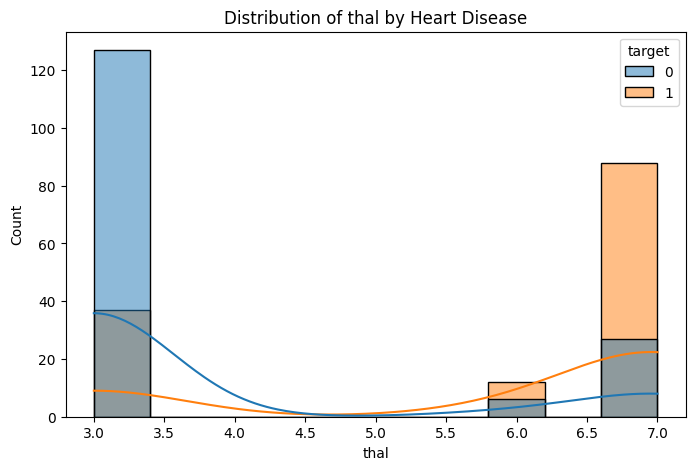


Logistic Regression Evaluation:
Accuracy: 0.8533333333333334
Confusion Matrix:
 [[35  5]
 [ 6 29]]
ROC AUC Score: 0.9478571428571428


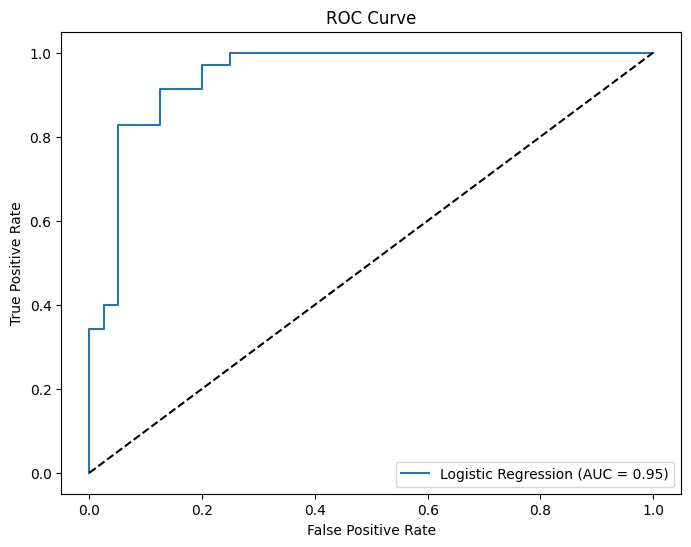

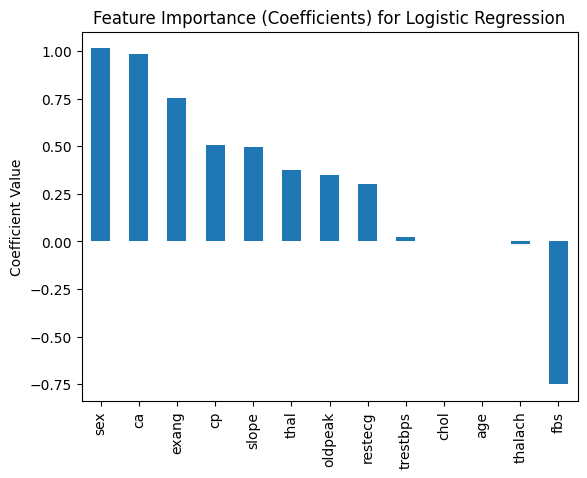


Decision Tree Evaluation:
Accuracy: 0.76
Confusion Matrix:
 [[33  7]
 [11 24]]
ROC AUC Score: 0.7553571428571428


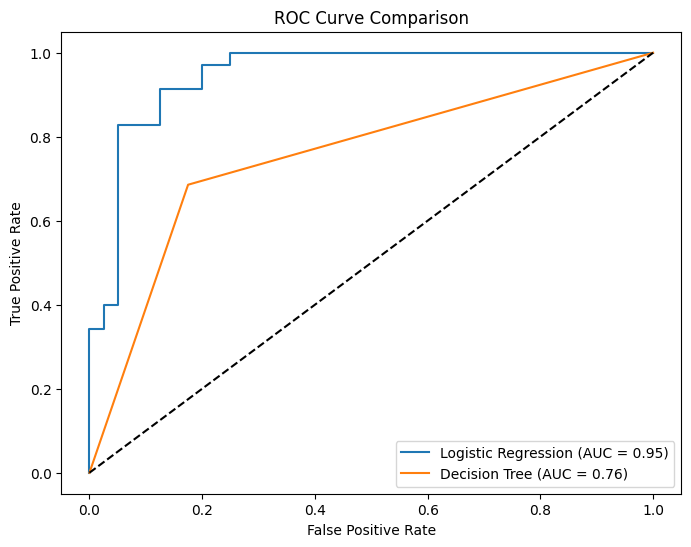

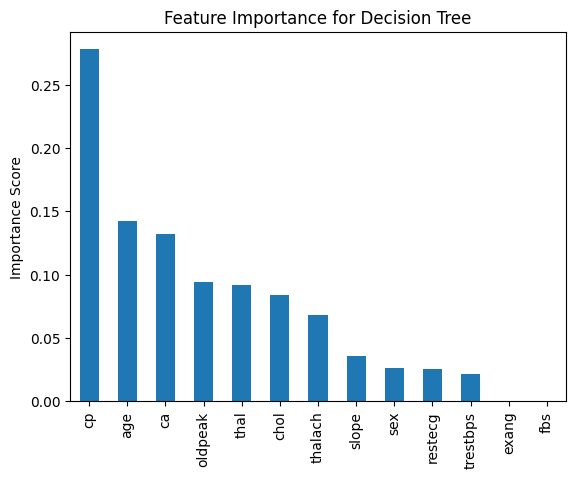

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data -O heart.csv

# Load the dataset
# The dataset does not have headers, so we'll provide them
# It also uses '?' for missing values
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv('heart.csv', names=column_names, na_values='?')

# Handle missing values by dropping rows with NaNs
df.dropna(inplace=True)

# Convert target column to binary (0 for no disease, 1 for disease)
# The original dataset has values > 0 for disease, so we convert them to 1
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Shape of the dataset after cleaning:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nMissing values after cleaning:\n", df.isnull().sum())

# EDA
# Distribution of the target variable
sns.countplot(x='target', data=df)
plt.title("Distribution of Heart Disease (0: No, 1: Yes)")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Heart Disease Dataset Features")
plt.show()

# Feature distributions by target
for column in df.columns[:-1]: # Exclude the target column
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, hue='target', kde=True)
    plt.title(f"Distribution of {column} by Heart Disease")
    plt.show()

# Split data into training and testing sets
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression model
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix:\n", cm_log_reg)

fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_prob_log_reg)
auc_log_reg = roc_auc_score(y_test, y_prob_log_reg)
print("ROC AUC Score:", auc_log_reg)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature Importance for Logistic Regression (coefficients)
feature_importance_log_reg = pd.Series(log_reg.coef_[0], index=X.columns)
feature_importance_log_reg.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance (Coefficients) for Logistic Regression")
plt.ylabel("Coefficient Value")
plt.show()


# Train a Decision Tree model
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)
y_pred_dec_tree = dec_tree.predict(X_test)
y_prob_dec_tree = dec_tree.predict_proba(X_test)[:, 1]


# Evaluate Decision Tree model
print("\nDecision Tree Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dec_tree))

cm_dec_tree = confusion_matrix(y_test, y_pred_dec_tree)
print("Confusion Matrix:\n", cm_dec_tree)

fpr_dec_tree, tpr_dec_tree, _ = roc_curve(y_test, y_prob_dec_tree)
auc_dec_tree = roc_auc_score(y_test, y_prob_dec_tree)
print("ROC AUC Score:", auc_dec_tree)

# Plot ROC curve for Decision Tree (on the same plot for comparison)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f'Logistic Regression (AUC = {auc_log_reg:.2f})')
plt.plot(fpr_dec_tree, tpr_dec_tree, label=f'Decision Tree (AUC = {auc_dec_tree:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


# Feature Importance for Decision Tree
feature_importance_dec_tree = pd.Series(dec_tree.feature_importances_, index=X.columns)
feature_importance_dec_tree.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance for Decision Tree")
plt.ylabel("Importance Score")
plt.show()

In [ ]:


!pip install openai

import openai
import os

try:
  openai.api_key = os.environ['OPENAI_API_KEY']
except KeyError:
  print("Please add your OpenAI API key as a Colab Secret named 'OPENAI_API_KEY'.")
  print("Go to the left sidebar, click the key icon (Secrets), and add it there.")



def get_health_response(query):
    """
    Sends a health-related query to the LLM with prompt engineering and safety filters.
    """
    if not openai.api_key:
        return "API key not set. Cannot process the request."

    # Basic safety check: Filter out potentially harmful queries upfront
    # This is a very basic example; a real-world application would need more robust filtering
    query_lower = query.lower()
    if any(keyword in query_lower for keyword in ['cure cancer', 'diagnose me', 'replace doctor']):
        return "I cannot provide medical diagnoses or replace professional medical advice. Please consult a qualified healthcare provider."

    # Prompt Engineering
    # - Act like a helpful but cautious medical assistant
    # - Emphasize that the information is general and not a substitute for professional advice
    # - Ask clarifying questions or suggest seeing a doctor when appropriate
    prompt = f"""Act as a helpful and informative medical assistant. Provide general information based on common knowledge, but never give medical advice, diagnosis, or treatment recommendations. Always emphasize that the user should consult a qualified healthcare professional for any health concerns.

User query: {query}

Assistant response:"""

    try:
        response = openai.ChatCompletion.create(
            model="gpt-3.5-turbo", # Or another available model
            messages=[
                {"role": "system", "content": "You are a helpful medical assistant providing general information. Do NOT provide medical advice, diagnoses, or treatment plans. Always tell the user to consult a healthcare professional."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=200,
            temperature=0.7
        )
        return response.choices[0].message['content'].strip()
    except Exception as e:
        return f"An error occurred: {e}"

# Example usage
print("Welcome to the General Health Information Chatbot (Beta).")
print("Please note: I provide general information only and DO NOT give medical advice.")
print("Always consult a qualified healthcare professional for any health concerns.")
print("Type 'quit' or 'exit' to end the chat.")

while True:
    user_input = input("\nYou: ")
    if user_input.lower() in ['quit', 'exit']:
        print("Goodbye!")
        break

    response = get_health_response(user_input)
    print(f"Bot: {response}")

# Example queries to test:
# print("\nTesting examples:")
# print(f"\nQuery: What causes a sore throat?")
# print(f"Bot: {get_health_response('What causes a sore throat?')}")
#
# print(f"\nQuery: Is paracetamol safe for children?")
# print(f"Bot: {get_health_response('Is paracetamol safe for children?')}")
#
# print(f"\nQuery: How to cure common cold?")
# print(f"Bot: {get_health_response('How to cure common cold?')}")
#
# print(f"\nQuery: Diagnose my headache.")
# print(f"Bot: {get_health_response('Diagnose my headache.')}")


Please add your OpenAI API key as a Colab Secret named 'OPENAI_API_KEY'.
Go to the left sidebar, click the key icon (Secrets), and add it there.
Welcome to the General Health Information Chatbot (Beta).
Please note: I provide general information only and DO NOT give medical advice.
Always consult a qualified healthcare professional for any health concerns.
Type 'quit' or 'exit' to end the chat.

You: Untitled3.ipynb
Bot: API key not set. Cannot process the request.

You: faizan
Bot: API key not set. Cannot process the request.

You: OPENAI_API_KEY
Bot: API key not set. Cannot process the request.


KeyboardInterrupt: Interrupted by user

In [ ]:

!pip install transformers datasets accelerate peft

from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import load_dataset

# --- Configuration ---
# Choose a model (smaller ones are faster for fine-tuning)
model_name = "distilgpt2" # Or "gpt2", "gpt2-medium", "gpt2-large", etc.
# model_name = "EleutherAI/gpt-neo-125M" # Another option
# For Mistral-7B, you would need more resources (GPU RAM) and potentially PEFT

dataset_name = "empathetic_dialogues"
output_dir = "./results_chatbot"
model_output_dir = "./chatbot_model"

# --- Load Model and Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Add a padding token if the tokenizer doesn't have one
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})

model = AutoModelForCausalLM.from_pretrained(model_name)
# Resize token embeddings if a new pad token was added
if tokenizer.pad_token == '[PAD]':
    model.resize_token_embeddings(len(tokenizer))

# --- Load and Prepare Dataset ---
dataset = load_dataset(dataset_name)

# We want to fine-tune the model to generate the 'response' given the 'prompt'
# The dataset format is 'speaker', 'utterance', 'context', 'relation', 'prompt', 'response'
# We will concatenate 'prompt' and 'response' and use Language Modeling approach

def tokenize_function(examples):
    # Concatenate prompt and response with a separator
    # Using a special token like EOS or a custom separator can help the model
    # understand where the input ends and generation should start.
    # Let's use the EOS token, common for generation tasks.
    text = [p + tokenizer.eos_token + r for p, r in zip(examples['prompt'], examples['response'])]
    # Tokenize the combined text
    tokenized_inputs = tokenizer(
        text,
        padding="max_length",  # Pad to max length or a fixed length
        truncation=True,
        max_length=256 # Choose a reasonable max length
    )
    # For causal language modeling, the labels are the input tokens shifted
    # We just use the same input_ids as labels for simplicity with Trainer
    tokenized_inputs["labels"] = tokenized_inputs["input_ids"].copy()
    return tokenized_inputs

# Apply tokenization to the dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=dataset['train'].column_names)

# Use a smaller subset for faster training during development
# tokenized_dataset["train"] = tokenized_dataset["train"].select(range(1000))
# tokenized_dataset["validation"] = tokenized_dataset["validation"].select(range(100))

# --- Define Training Arguments ---
training_args = TrainingArguments(
    output_dir=output_dir,
    overwrite_output_dir=True,
    num_train_epochs=3,          # Number of epochs
    per_device_train_batch_size=4, # Batch size per GPU/CPU for training
    per_device_eval_batch_size=4,  # Batch size per GPU/CPU for evaluation
    eval_strategy="epoch",       # Evaluate at the end of each epoch
    logging_dir="./logs",        # Directory for storing logs
    logging_steps=100,
    save_strategy="epoch",       # Save model checkpoints at the end of each epoch
    save_total_limit=2,          # Limit the number of saved checkpoints
    load_best_model_at_end=True, # Load the best model at the end of training
    metric_for_best_model="eval_loss", # Use evaluation loss to determine the best model
    greater_is_better=False,     # Lower loss is better
    # Learning rate and schedule
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=100,
    # Other potentially useful args:
    # gradient_accumulation_steps=2, # Accumulate gradients over multiple batches
    # fp16=True, # Use mixed precision training (requires compatible GPU)
)

# --- Initialize the Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer, # Pass the tokenizer to the trainer
    # Data collator for causal language modeling
    # The default DataCollatorForLanguageModeling can handle padding and shifting labels
)

# --- Train the Model ---
print("Starting model training...")
trainer.train()
print("Training finished.")

# --- Save the fine-tuned model ---
trainer.save_model(model_output_dir)
print(f"Fine-tuned model saved to {model_output_dir}")

# --- Simple Command-Line Interface ---

# Load the fine-tuned model and tokenizer
print("\nLoading the fine-tuned model for inference...")
loaded_tokenizer = AutoTokenizer.from_pretrained(model_output_dir)
loaded_model = AutoModelForCausalLM.from_pretrained(model_output_dir)

# Ensure the loaded tokenizer also has a pad token if added during training
if loaded_tokenizer.pad_token is None:
     loaded_tokenizer.add_special_tokens({'pad_token': '[PAD]'})
     loaded_model.resize_token_embeddings(len(loaded_tokenizer))


print("Mental Health Support Chatbot (Fine-Tuned)")
print("Type 'quit' or 'exit' to end the conversation.")

def generate_response(prompt_text, model, tokenizer, max_length=150, temperature=0.8, top_k=50, top_p=0.95, num_return_sequences=1):
    """Generates a response from the fine-tuned model."""
    # Add the EOS token to indicate the end of the prompt
    input_text = prompt_text + tokenizer.eos_token
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device) # Move to GPU if available

    # Generate response
    output = model.generate(
        input_ids,
        max_length=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        num_return_sequences=num_return_sequences,
        pad_token_id=tokenizer.pad_token_id # Use the pad token ID
    )

    # Decode the generated text
    generated_text = tokenizer.decode(output[0], skip_special_tokens=False) # Keep special tokens initially

    # Find the generated response part after the EOS token
    # The format is "prompt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 881.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Generating train split:   0%|          | 0/76673 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12030 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10943 [00:00<?, ? examples/s]

NotImplementedError: Loading a dataset cached in a LocalFileSystem is not supported.

Dataset Head:
   SquareFootage  Bedrooms  Bathrooms Neighborhood  YearBuilt          Price
0           4829         4          2        Rural       1992  801614.287521
1           1225         3          3     Suburb A       2001  379519.094839
2           3431         4          2     Downtown       1991  751394.365372
3           1644         1          3     Downtown       1991  445469.599908
4           3525         2          2     Suburb B       2001  553761.780704

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SquareFootage  1000 non-null   int64  
 1   Bedrooms       1000 non-null   int64  
 2   Bathrooms      1000 non-null   int64  
 3   Neighborhood   1000 non-null   object 
 4   YearBuilt      1000 non-null   int64  
 5   Price          1000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage

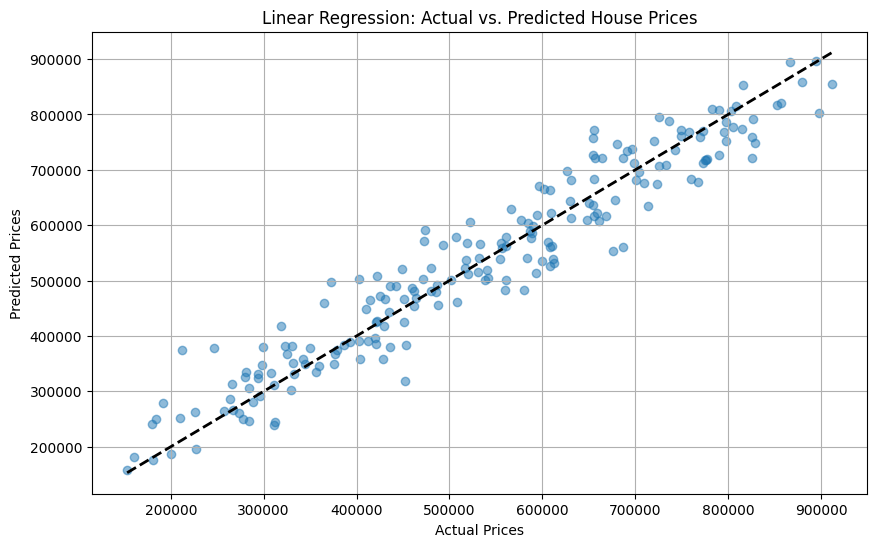

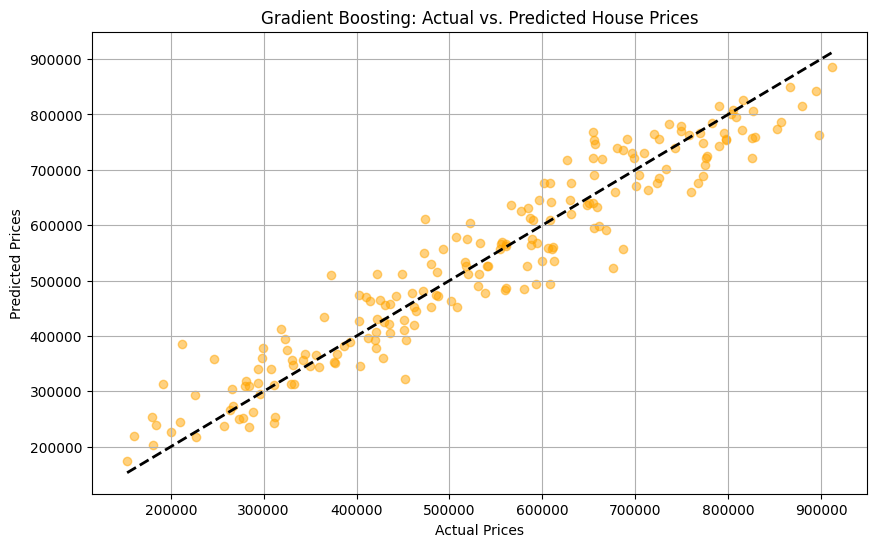

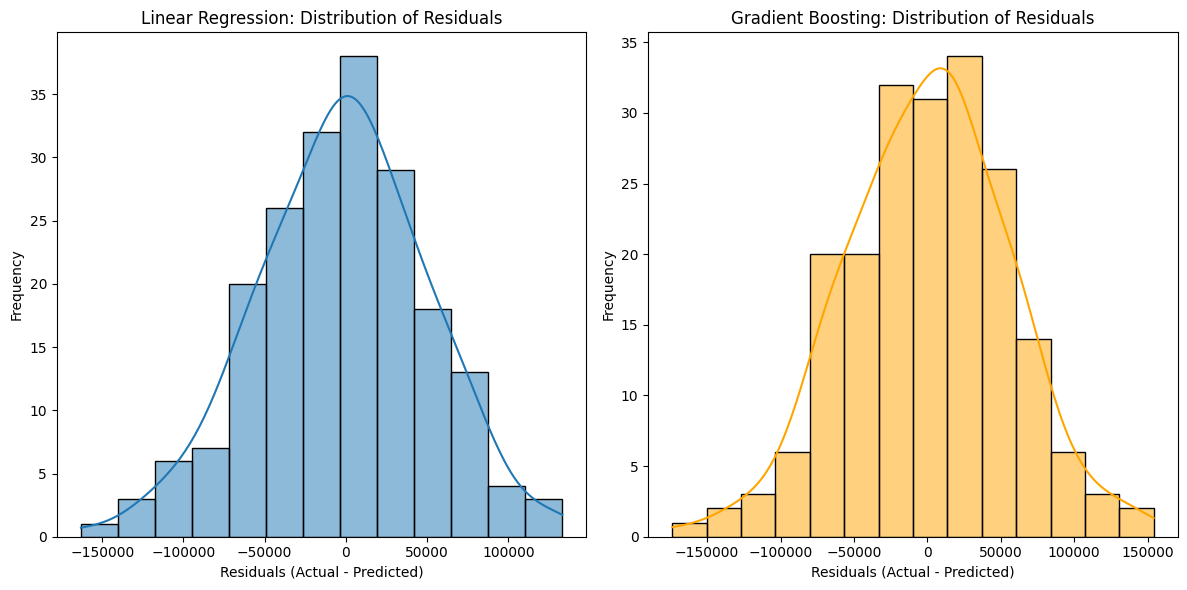

In [1]:
!pip install pandas scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
# Assuming the dataset is available as a CSV file in the environment
# You might need to upload it or download it from Kaggle
# For demonstration, let's create a dummy dataset simulating house data
data = {
    'SquareFootage': np.random.randint(800, 5000, 1000),
    'Bedrooms': np.random.randint(1, 6, 1000),
    'Bathrooms': np.random.randint(1, 4, 1000),
    'Neighborhood': np.random.choice(['Downtown', 'Suburb A', 'Suburb B', 'Rural'], 1000),
    'YearBuilt': np.random.randint(1950, 2023, 1000),
    'Price': np.random.randint(150000, 1500000, 1000)
}
df = pd.DataFrame(data)

# Simulate some correlation with price
df['Price'] = (df['SquareFootage'] * 150 +
               df['Bedrooms'] * 20000 +
               df['Bathrooms'] * 15000 +
               (df['Neighborhood'].apply(lambda x: {'Downtown': 100000, 'Suburb A': 50000, 'Suburb B': 30000, 'Rural': 10000}[x])) +
               (2024 - df['YearBuilt']) * -1000 + # Newer houses are slightly more expensive
               np.random.randn(1000) * 50000) # Add some noise
df['Price'] = np.maximum(100000, df['Price']) # Ensure minimum price

print("Dataset Head:")
print(df.head())
print("\nDataset Info:")
df.info()
print("\nDataset Description:")
print(df.describe())

# Preprocessing: Identify numerical and categorical features
numerical_features = ['SquareFootage', 'Bedrooms', 'Bathrooms', 'YearBuilt']
categorical_features = ['Neighborhood'] # Assuming Neighborhood is the only categorical feature needing encoding

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler() # Scale numerical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like the target 'Price') if any, although we'll drop it below
)

# Split data into features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Create the full pipeline including preprocessing and the model
# Option 1: Linear Regression
linear_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('regressor', LinearRegression())])

# Option 2: Gradient Boosting Regressor
gbm_model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))])


# Train the models
print("\nTraining Linear Regression Model...")
linear_model_pipeline.fit(X_train, y_train)
print("Linear Regression Training Complete.")

print("\nTraining Gradient Boosting Regressor Model...")
gbm_model_pipeline.fit(X_train, y_train)
print("Gradient Boosting Regressor Training Complete.")


# Make predictions
linear_predictions = linear_model_pipeline.predict(X_test)
gbm_predictions = gbm_model_pipeline.predict(X_test)


# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")
    return mae, rmse, r2

linear_mae, linear_rmse, linear_r2 = evaluate_model(y_test, linear_predictions, "Linear Regression")
gbm_mae, gbm_rmse, gbm_r2 = evaluate_model(y_test, gbm_predictions, "Gradient Boosting Regressor")


# Visualize predicted prices vs actual prices

# For Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, linear_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ideal line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()

# For Gradient Boosting Regressor
plt.figure(figsize=(10, 6))
plt.scatter(y_test, gbm_predictions, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Ideal line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Gradient Boosting: Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()

# Plotting the distribution of errors (residuals)
linear_residuals = y_test - linear_predictions
gbm_residuals = y_test - gbm_predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(linear_residuals, kde=True)
plt.title("Linear Regression: Distribution of Residuals")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(gbm_residuals, kde=True, color='orange')
plt.title("Gradient Boosting: Distribution of Residuals")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()